# Intégration de l'ENMO par époque (10 s, 30 s, 60 s)

**Dépôt GitHub :** [https://github.com/TON-COMPTE/TON-DEPOT](https://github.com/TON-COMPTE/TON-DEPOT)

**Équipe :** Prénom Nom, Prénom Nom, Prénom Nom

## 0. Objectif et démarche

On dispose de quelques minutes de données brutes d'un accéléromètre **Axivity AX3** porté au poignet non dominant (`0_z.csv` : `t` en secondes, `x`, `y`, `z` en g).
Les données brutes (50 échantillons par seconde) sont trop détaillées pour décrire l'activité physique. On les résume donc en trois temps :

1. **Charger** les données ;
2. **Calculer l'ENMO** à chaque échantillon (mesure de l'intensité du mouvement, indépendante de l'orientation du capteur) ;
3. **Intégrer** l'ENMO sur des **époques** (fenêtres de temps) de 10 s, 30 s et 60 s, puis tracer.

## 1. Chargement des données

Le fichier commence par une ligne de commentaire (`# accelerometer data in g`) : on l'ignore avec `comment="#"`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_data(path):
    """Charge le CSV (t en s, x/y/z en g) en ignorant la ligne de commentaire."""
    return pd.read_csv(path, comment="#")

df = load_data("0_z.csv")
print(df.shape)
df.head()

### Vérification de la fréquence d'échantillonnage

La fréquence justifie le découpage en époques : chaque époque contiendra `fréquence × durée` échantillons.

In [ ]:
def sampling_info(df):
    """Renvoie (fréquence en Hz, durée totale en s)."""
    dt = df["t"].diff().mean()
    return 1 / dt, df["t"].iloc[-1]

fs, duration = sampling_info(df)
print(f"Fréquence : {fs:.0f} Hz | Durée : {duration:.0f} s | Valeurs manquantes : {df.isna().sum().sum()}")

Fréquence : 50 Hz | Durée : 420 s | Valeurs manquantes : 0


## 2. Calcul de l'ENMO à chaque échantillon

**ENMO** = *Euclidean Norm Minus One* :

$$\text{ENMO} = \max\left(\sqrt{x^2 + y^2 + z^2} - 1,\ 0\right)$$

- La **norme euclidienne** (vector magnitude) combine les trois axes : le résultat ne dépend pas de l'orientation du capteur sur le poignet.
- On **retire 1 g** : au repos, le capteur mesure uniquement la gravité (≈ 1 g). Ce qui reste est l'accélération due au mouvement.
- Le `max(..., 0)` évite les valeurs négatives comme le bruit par exemple

In [ ]:
def compute_enmo(df):
    """ENMO (en g) pour chaque échantillon : max(||(x, y, z)|| - 1, 0)."""
    vm = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)
    return np.maximum(vm - 1, 0)

enmo = compute_enmo(df)
print(f"ENMO moyen : {enmo.mean()*1000:.1f} mg | maximum : {enmo.max()*1000:.0f} mg")

ENMO moyen : 51.3 mg | maximum : 12785 mg


### Visualisation de l'ENMO brut

On regarde le signal avant de l'intégrer : on repère les périodes calmes (proches de 0) et les pics de mouvement.

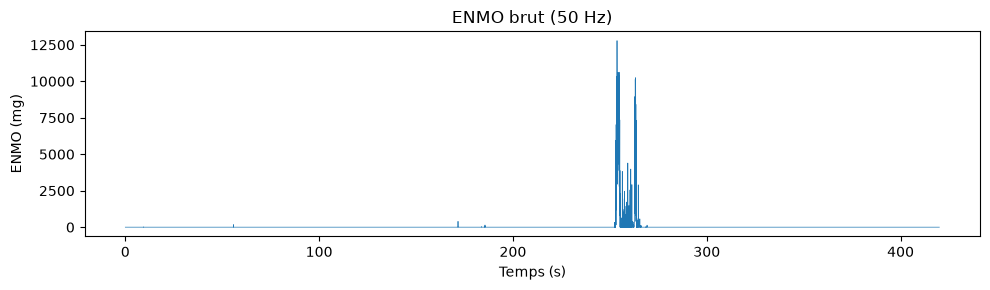

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df["t"], enmo * 1000, lw=0.5)
ax.set_xlabel("Temps (s)")
ax.set_ylabel("ENMO (mg)")
ax.set_title("ENMO brut (50 Hz)")
plt.tight_layout()
plt.show()

## 3. Intégration de l'ENMO par époque

Une **époque** est une fenêtre de temps de durée fixe. Pour chaque époque, on résume l'ENMO en une seule valeur.

**Choix : la moyenne** (en mg, 1 g = 1000 mg). On préfère la moyenne à la somme car elle ne dépend pas de la longueur de l'époque : les valeurs obtenues avec 10 s, 30 s et 60 s restent **comparables**. (La somme serait proportionnelle à la durée, donc trois fois plus grande en 30 s qu'en 10 s pour la même activité.)

**Méthode** : `t // epoch_s` donne le numéro de l'époque de chaque échantillon, puis on regroupe (`groupby`) et on fait la moyenne. Ici 420 s se divise exactement par 10, 30 et 60 : aucune époque incomplète.

In [ ]:
def epoch_enmo(df, enmo, epoch_s):
    """ENMO moyen (en mg) pour chaque époque de epoch_s secondes."""
    epoch_id = (df["t"] // epoch_s).astype(int)
    return enmo.groupby(epoch_id).mean() * 1000

for ep in (10, 30, 60):
    res = epoch_enmo(df, enmo, ep)
    print(f"Époque {ep:>2} s : {len(res)} époques | moyenne {res.mean():.1f} mg | max {res.max():.1f} mg")

Époque 10 s : 42 époques | moyenne 51.3 mg | max 1539.1 mg
Époque 30 s : 14 époques | moyenne 51.3 mg | max 717.6 mg
Époque 60 s : 7 époques | moyenne 51.3 mg | max 358.8 mg


## 4. Graphiques pour 10 s, 30 s et 60 s

Un graphique par durée d'époque, avec le même axe des temps pour comparer directement.

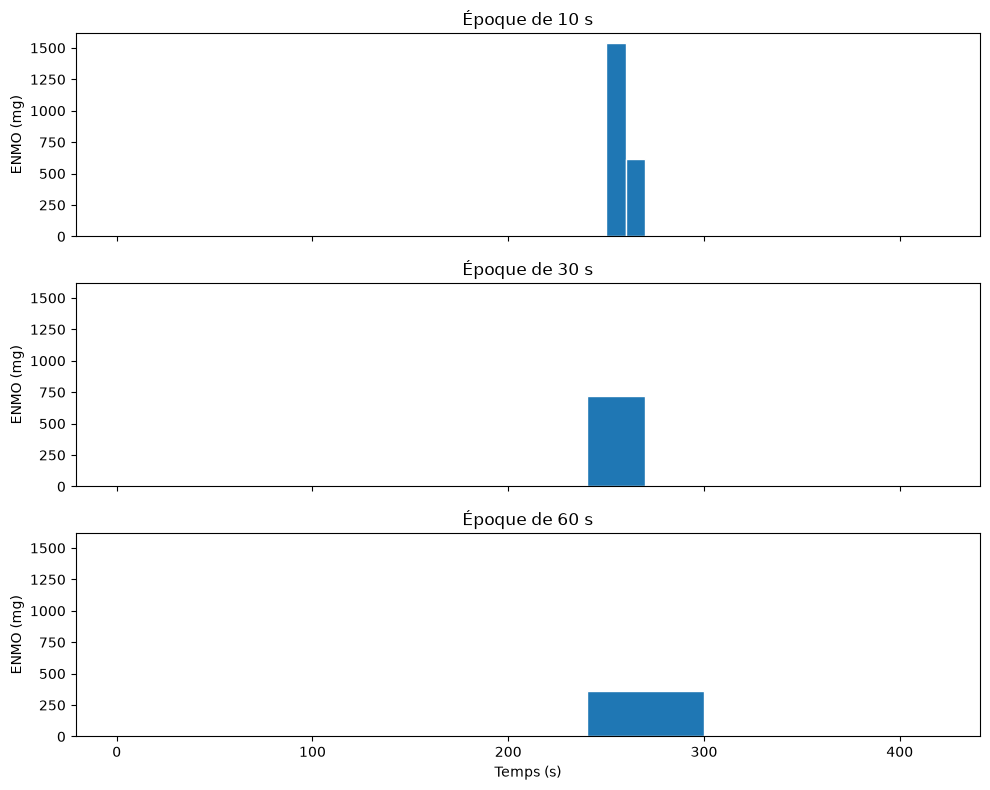

In [ ]:
def plot_epochs(df, enmo, epochs=(10, 30, 60)):
    """Trace l'ENMO moyen par époque, un panneau par durée d'époque."""
    fig, axes = plt.subplots(len(epochs), 1, figsize=(10, 8), sharex=True, sharey=True)
    for ax, ep in zip(axes, epochs):
        res = epoch_enmo(df, enmo, ep)
        ax.bar(res.index * ep, res.values, width=ep, align="edge", edgecolor="white")
        ax.set_title(f"Époque de {ep} s")
        ax.set_ylabel("ENMO (mg)")
    axes[-1].set_xlabel("Temps (s)")
    plt.tight_layout()
    plt.show()

plot_epochs(df, enmo)

## 5. Interprétation

- Plus l'époque est **courte** (10 s), plus on distingue les variations rapides et les pics d'activité brefs.
- Plus l'époque est **longue** (60 s), plus la courbe est **lissée** : on voit la tendance générale, mais les pics courts sont dilués dans la moyenne et donc sous-estimés.
- Le choix de l'époque est un compromis entre **précision temporelle** et **lisibilité / réduction du bruit**. Il dépend de la question posée (mouvements brefs ou niveau d'activité global).

## 6. Utilisation de Copilot

*(À compléter)*

| Prompt donné à Copilot | Suggestion obtenue | Ce que nous avons modifié après relecture |
|---|---|---|
| … | … | … |
| … | … | … |